In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.io import loadmat
from tifffile import TiffFile
import cv2

In [2]:
sys.path.append(r'C:\Users\97254\Desktop\git\FluoroVision')

In [3]:
from src.post_process.fluorophore_intensity import FluorophoreIntensityEstimator
from src.utils.common_utils import xcycwh_to_x1y1x2y2

#### Functions

In [4]:
def plot_bead_and_peaks(bead, peaks, cmap='gray'):
    plt.imshow(bead, cmap=cmap)
    for peak in peaks:
        plt.plot(peak[1], peak[0], 'ro', markersize=5, markeredgewidth=1)
    chbr = plt.colorbar(fraction=0.046, pad=0.04)
    chbr.set_label('Intensity')
    plt.show()

def plot_bead_and_mask(bead, mask, cmap='gray'):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    im1 = ax[0].imshow(bead, cmap=cmap)
    chbr = plt.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
    chbr.set_label('Intensity')
    ax[1].imshow(mask, cmap=cmap)
    plt.tight_layout()
    plt.show()

def plot_mask_with_peaks(mask, peaks, cmap='gray'):
    plt.imshow(mask, cmap=cmap)
    for peak in peaks:
        plt.plot(peak[1], peak[0], 'ro', markersize=5, markeredgewidth=1)
    plt.show()

#### Inputs

In [5]:
tif_path = r'c:\Users\97254\Desktop\Resources\Technion\exploratory_resaerach\fluorovision\data\A1\2025_02_05_A1.tif'

In [6]:
detection_path = r'c:\Users\97254\Desktop\Resources\Technion\exploratory_resaerach\fluorovision\data\A1\results\tracked_results.csv'

In [7]:
laser_map_path = r'C:\Users\97254\Desktop\git\FluoroVision\src\config\mapV2.mat'

In [8]:
df = pd.read_csv(detection_path)

In [9]:
df.head()

,frame,class,conf,x_center,y_center,width,height,track_id,fluoro_intensity,factor
0,9.0,0.0,0.266092,16.310041,156.003357,32.321514,6.135864,0.0,NaN,NaN
1,10.0,0.0,0.695648,54.765392,156.316101,45.257835,5.929077,0.0,194395.5,188.278042
2,11.0,0.0,0.731170,100.460327,157.082031,49.291435,6.097061,0.0,196282.0,204.395822
3,12.0,0.0,0.628140,152.684402,157.248688,61.114418,6.062973,0.0,73658.0,191.495954
4,13.0,0.0,0.729463,15.809977,191.138641,31.307251,4.857361,1.0,NaN,NaN


In [10]:
fie = FluorophoreIntensityEstimator(map_path=laser_map_path, peak_radius=3, filter_size=20)

In [15]:
def plot_first_derivative(array):
    dx, dy = np.gradient(array)

    # Plot the original array
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    # Plot the first derivative along the x-axis
    plt.subplot(1, 3, 2)
    plt.imshow(dx, cmap='viridis')
    plt.title('First Derivative (x-axis)')

    # Plot the first derivative along the y-axis
    plt.subplot(1, 3, 3)
    plt.imshow(dy, cmap='viridis')
    plt.title('First Derivative (y-axis)')

    plt.tight_layout()
    plt.show()

In [16]:
def create_gradient_based_mask(image, points, radius=3, gradient_threshold=10000):

    # Calculate the gradients
    dx, dy = np.gradient(image)
    gradient_magnitude = np.sqrt(dx**2 + dy**2)

    # Initialize the mask with ones (True)
    mask = np.ones_like(image, dtype=bool)

    # Remove areas around the points based on the gradients
    for point in points:
        y, x = point
        mask
        rr, cc = np.ogrid[:image.shape[0], :image.shape[1]]
        mask_area = (rr - y) ** 2 + (cc - x) ** 2 <= radius ** 2
        mask[mask_area & (gradient_magnitude > gradient_threshold)] = False
        mask[y,x] = False

    return mask

Processing frame 1...
Processing frame 2...
Processing frame 3...
Processing frame 4...
Processing frame 5...
Processing frame 6...
Processing frame 7...
Processing frame 8...
Processing frame 9...


Processing frame 10...


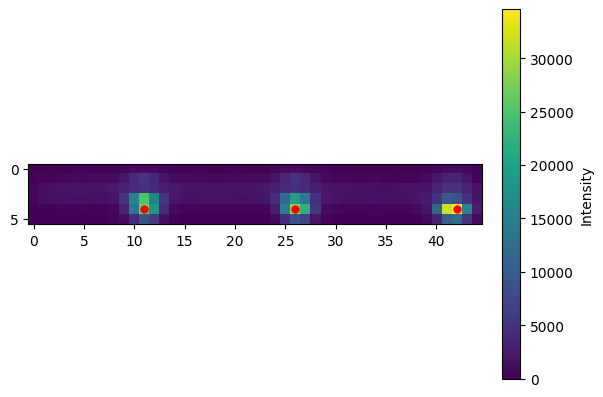

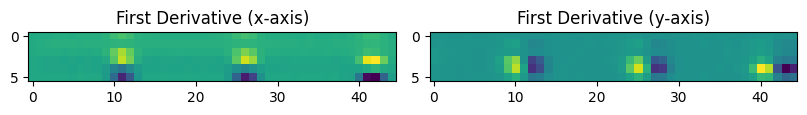

Optimal rectangle intensity: 900.12634797609


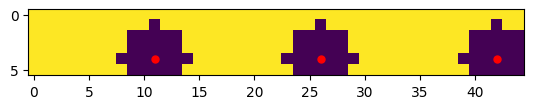

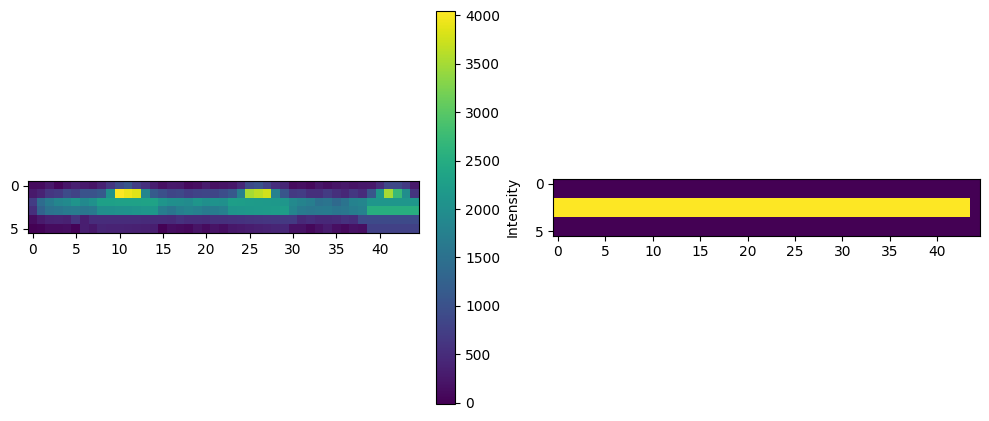

Optimal rectangle intensity: 837.6544071166302


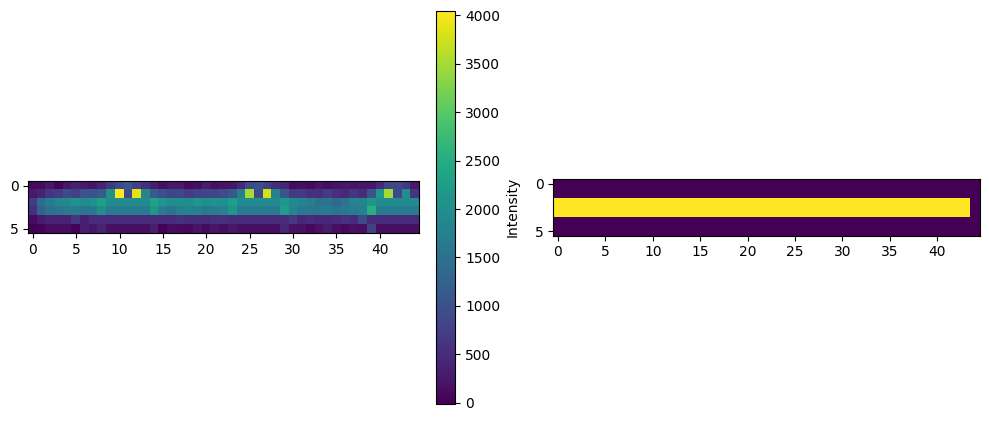

Processing frame 11...


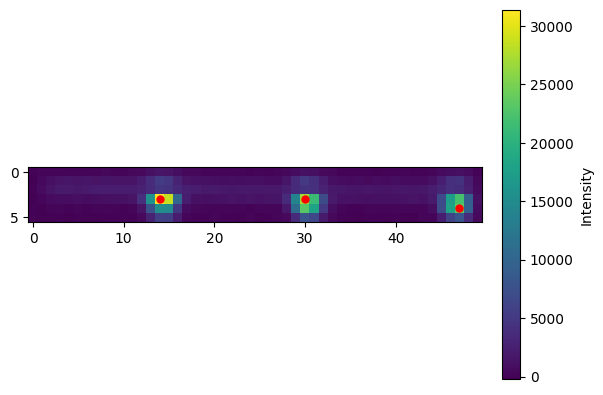

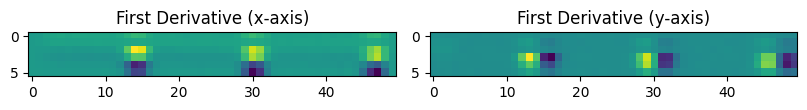

Optimal rectangle intensity: 1025.5898818126614


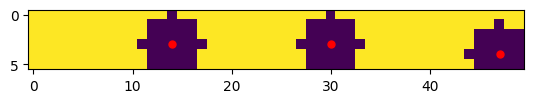

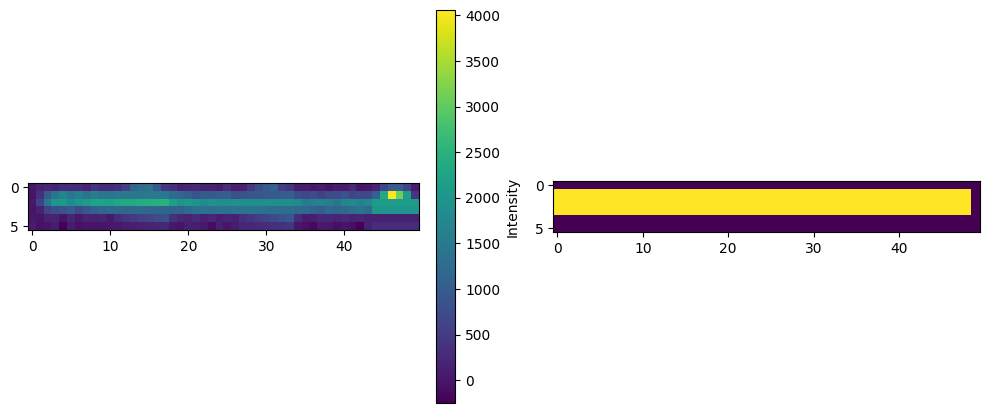

Optimal rectangle intensity: 969.4971252475627


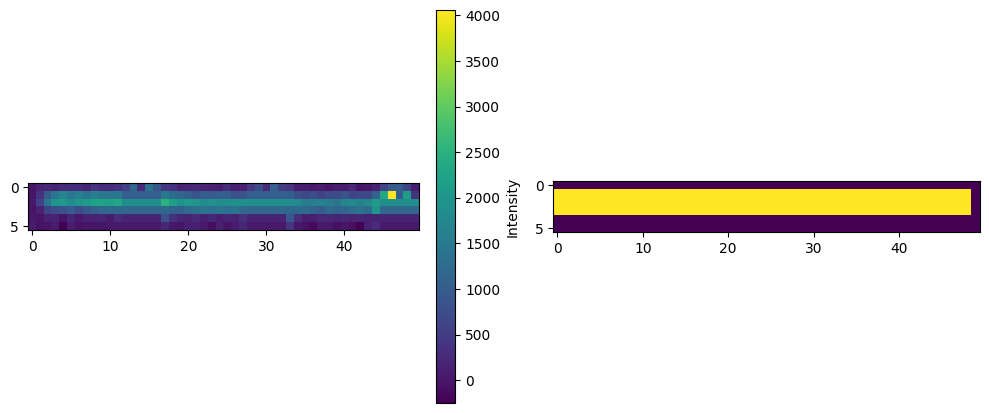

Processing frame 12...


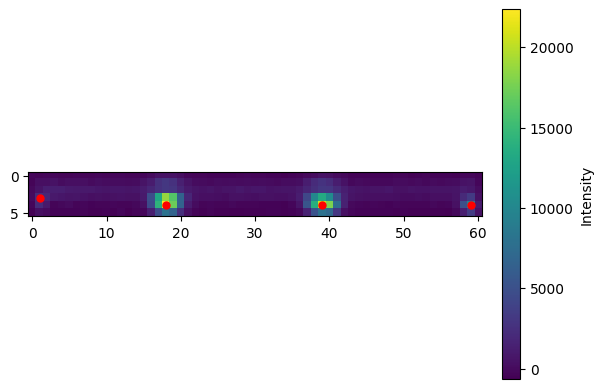

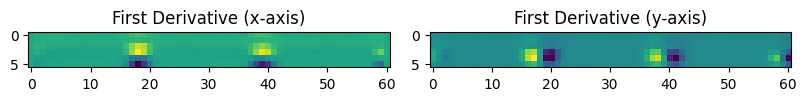

Optimal rectangle intensity: 431.0641264230117


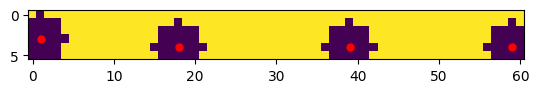

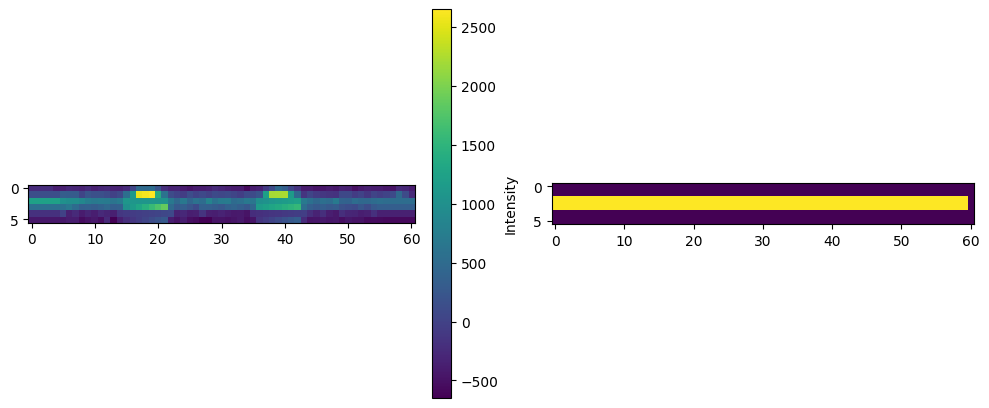

Optimal rectangle intensity: 338.07568878137795


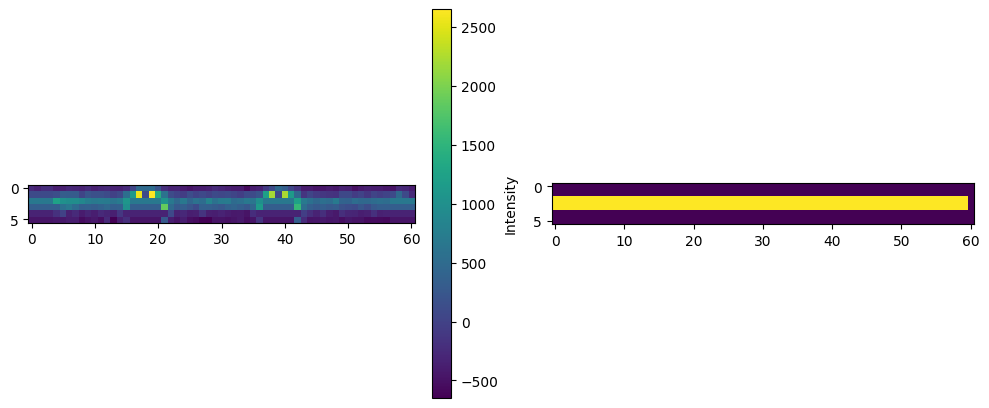

Processing frame 13...


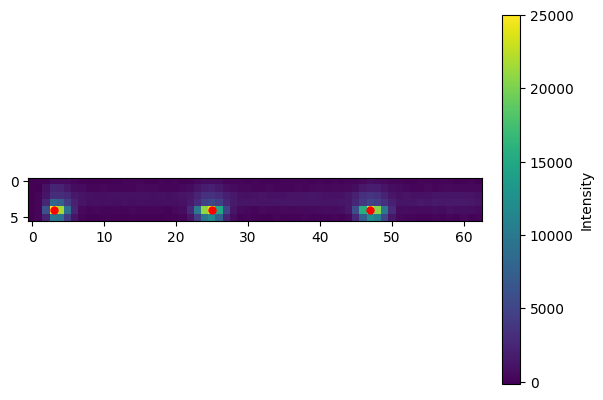

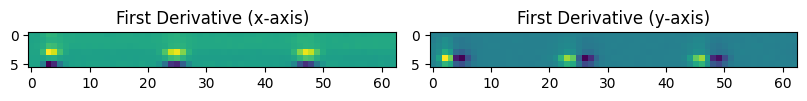

Optimal rectangle intensity: 792.5334240219032


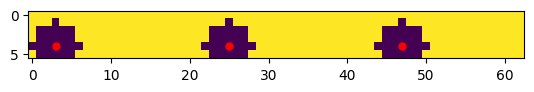

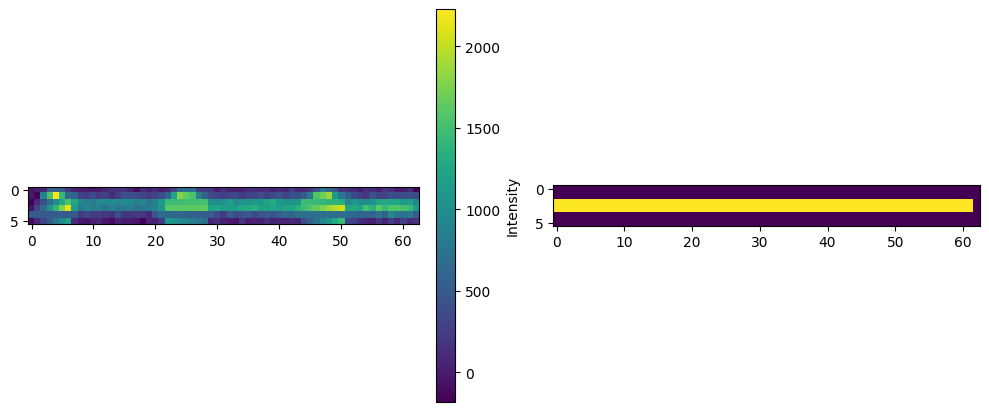

Optimal rectangle intensity: 759.0135526819221


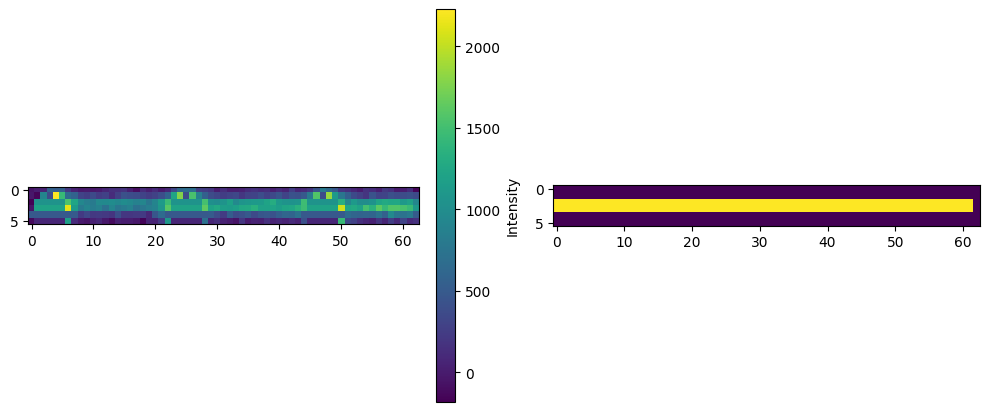

Processing frame 14...


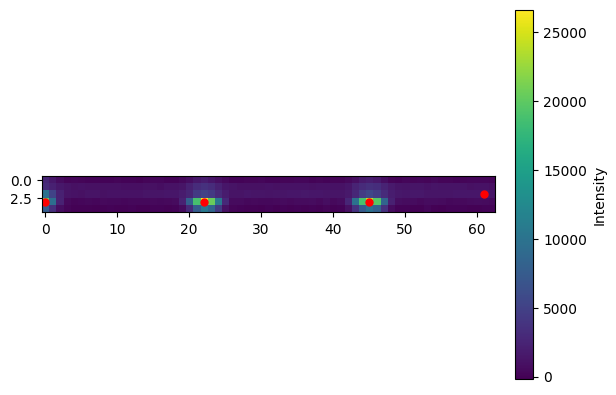

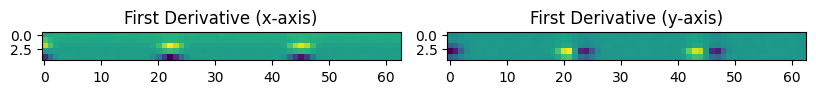

Optimal rectangle intensity: 788.9192394394219


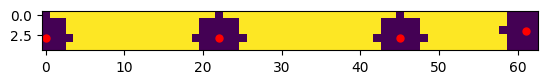

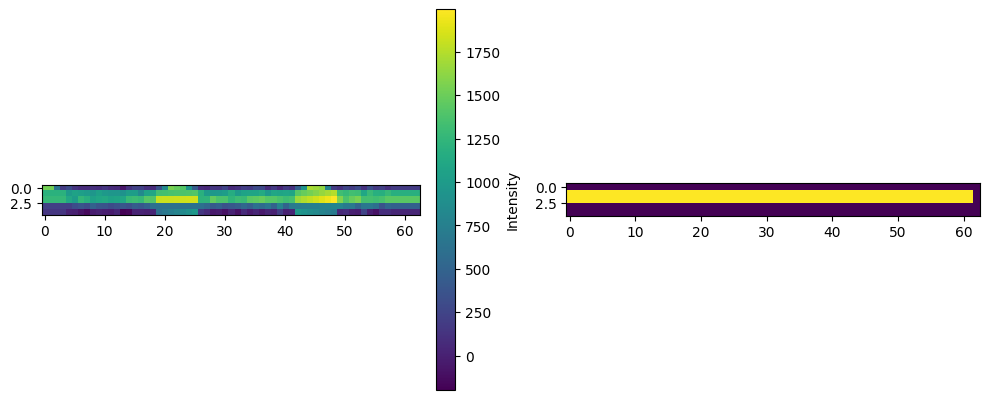

Optimal rectangle intensity: 741.9812025946607


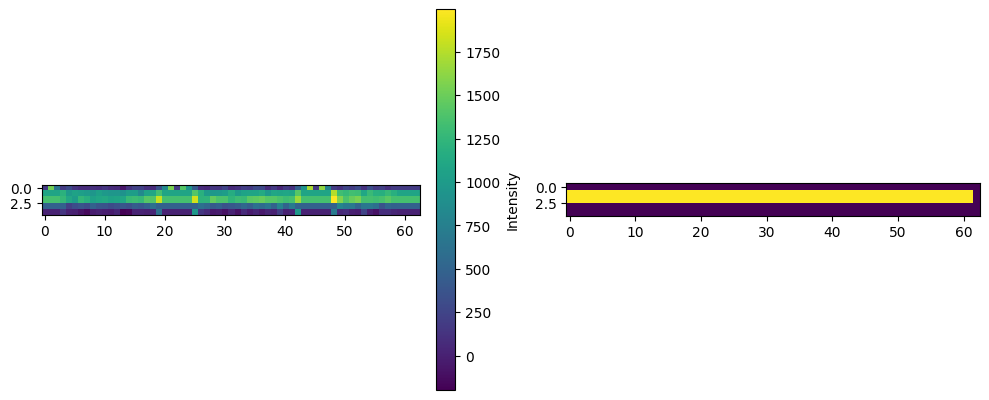

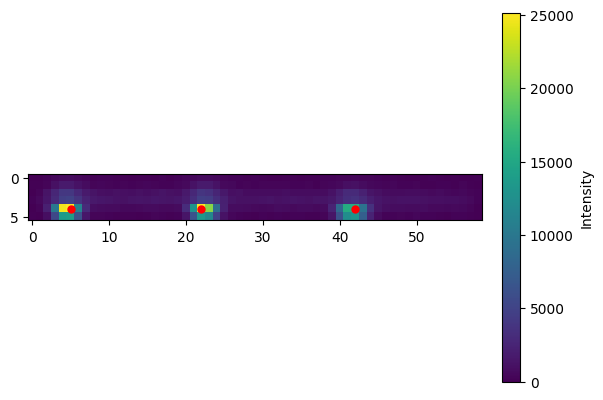

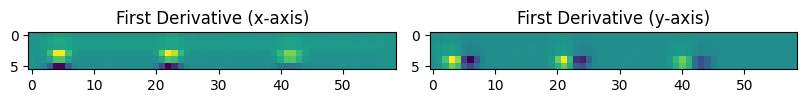

Optimal rectangle intensity: 1019.4259861199962


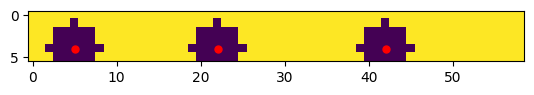

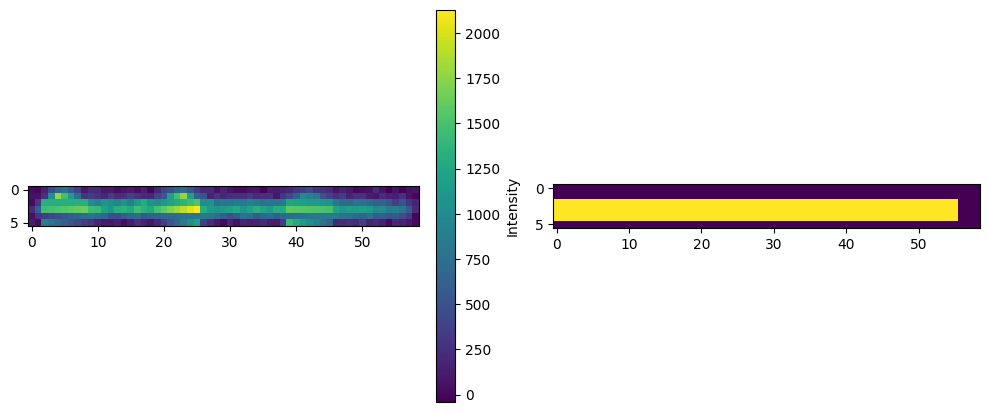

Optimal rectangle intensity: 935.9631497870026


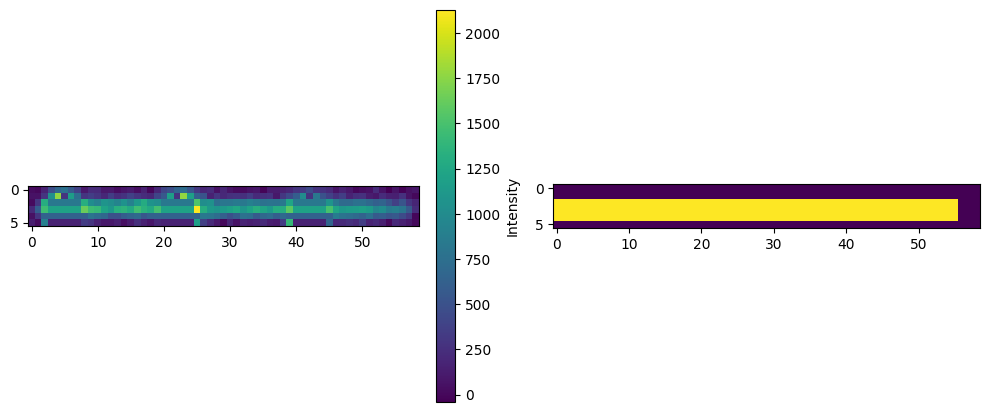

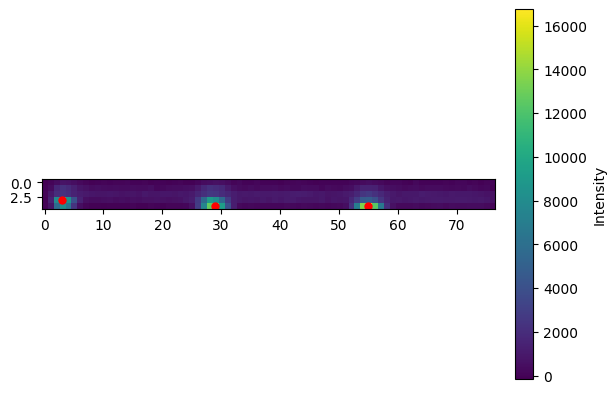

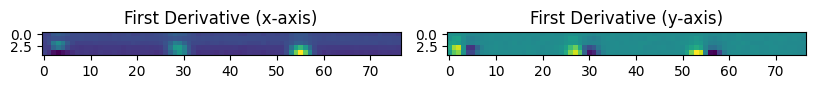

Optimal rectangle intensity: 759.6670753079304


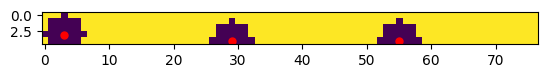

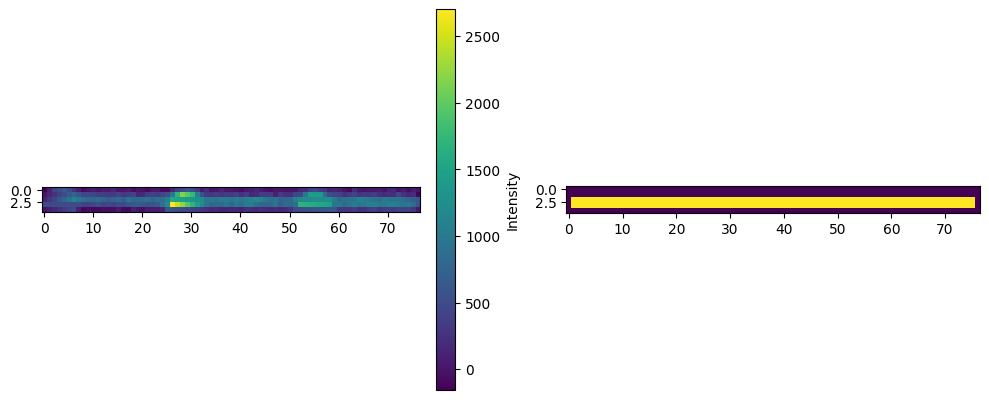

Optimal rectangle intensity: 715.204898861944


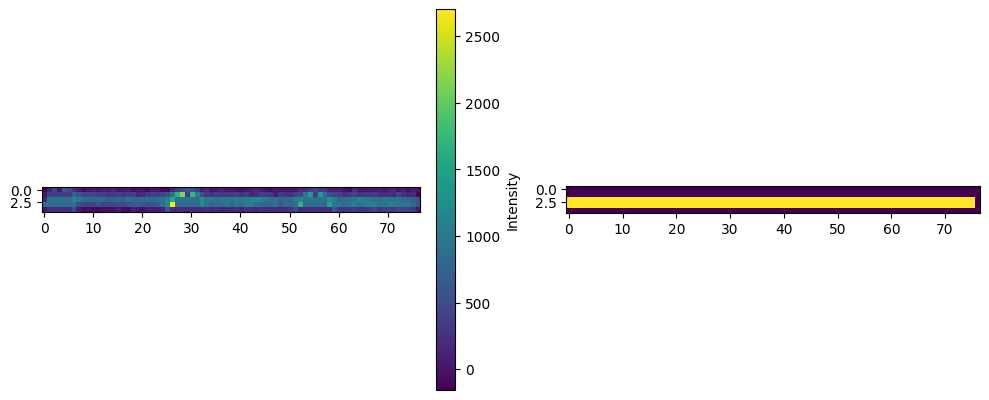

Processing frame 15...


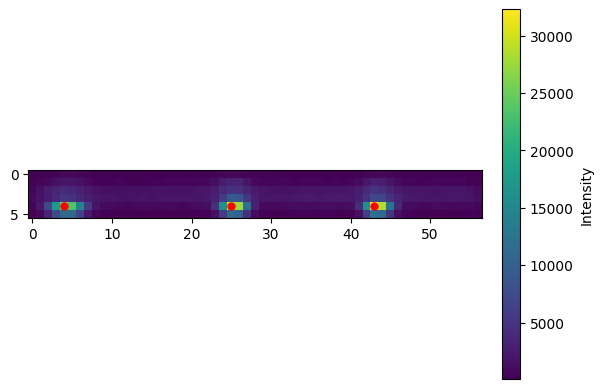

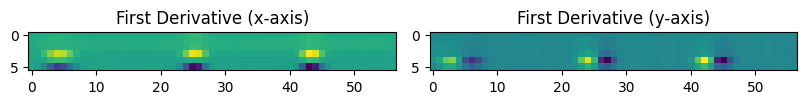

Optimal rectangle intensity: 1049.0774383239223


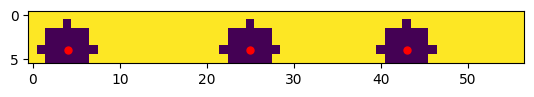

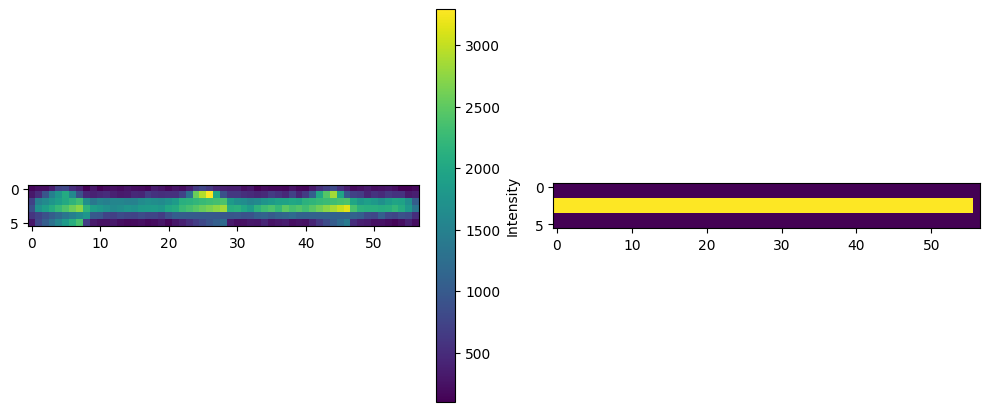

Optimal rectangle intensity: 990.2521327078372


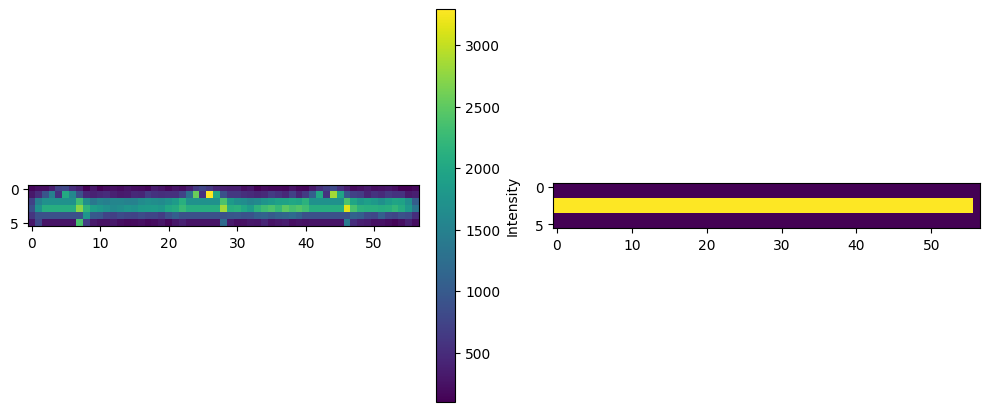

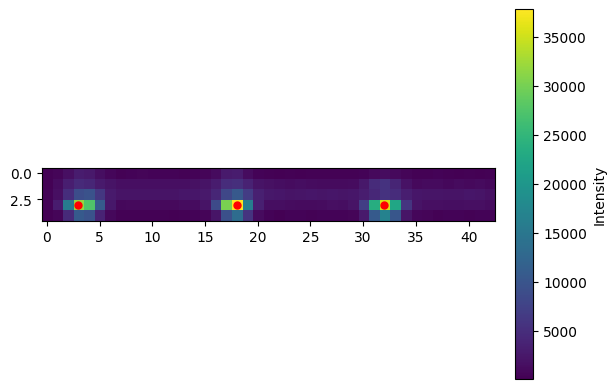

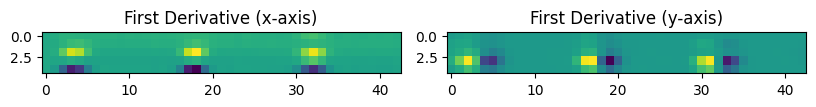

Optimal rectangle intensity: 1157.7342841026386


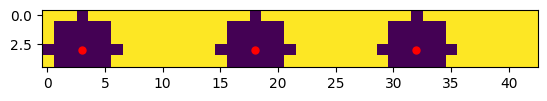

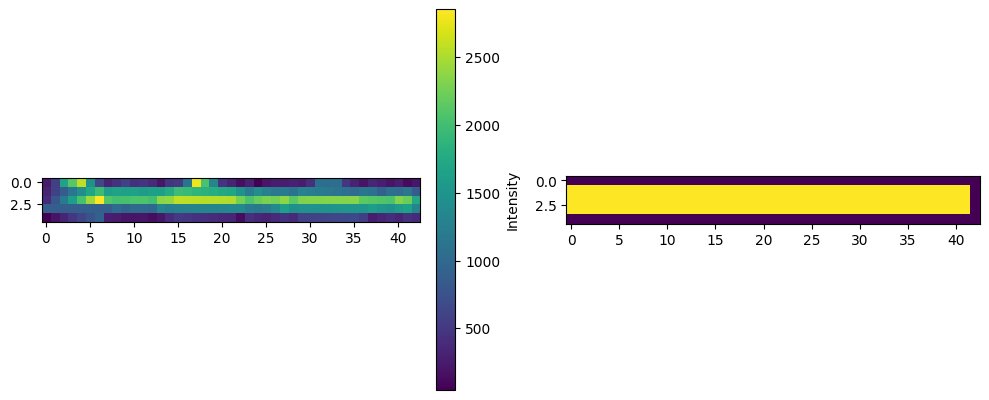

Optimal rectangle intensity: 1159.9046375565722


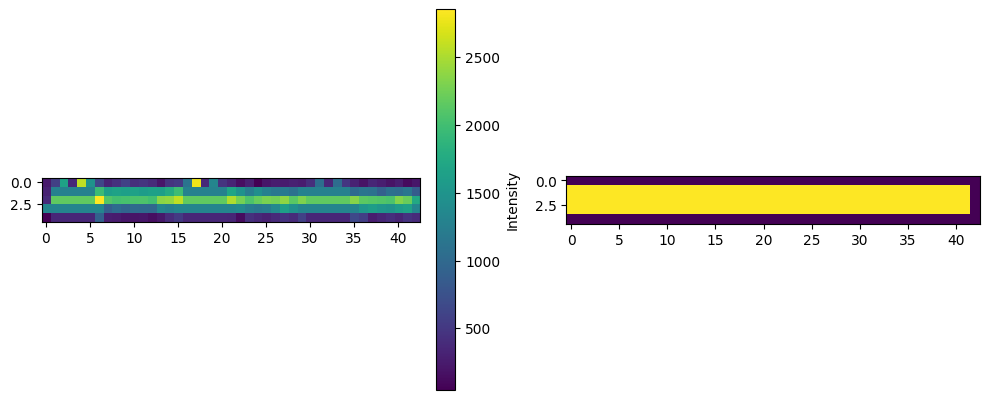

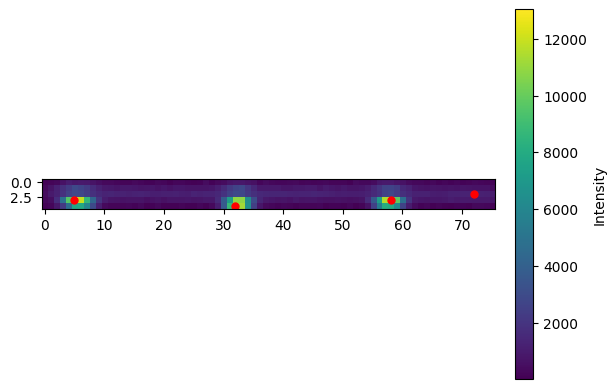

KeyboardInterrupt: 

In [ ]:
image_debug = 10

with TiffFile(tif_path) as tif:
    for i, page in enumerate(tif.pages):
        print(f'Processing frame {i+1}...')
        frame_df = df[df['frame'] == i+1]
        if frame_df.empty:
            continue
        boxes = frame_df.loc[:,['x_center', 'y_center', 'width', 'height']].to_numpy()
        frame = page.asarray()
        for box in boxes:
            x1, y1, x2, y2 = xcycwh_to_x1y1x2y2(box[0], box[1], box[2], box[3])
            bead = frame[y1:y2, x1:x2]
            peaks = fie.get_2d_peaks(bead)
            if len(peaks) < 3:
                continue
            plot_bead_and_peaks(bead, peaks, 'viridis')
            plot_first_derivative(bead)
            factor = fie.map[int(box[0]), int(box[1])]
            # peak radius method
            mask = fie.get_peak_mask_circle(bead, peaks)
            interpolated_image = fie.horizontal_axis_interpolation(bead, mask)
            _, _, closed_clusterd_array, _ = fie.kmean_cluster_2d_array(
            interpolated_image)
            optimal_mask = fie.get_optimal_rectangle(closed_clusterd_array)
            optimal_rectangle_intensity = np.sum(interpolated_image * optimal_mask)
            plot_mask_with_peaks(mask, peaks, 'viridis')
            print(f'Optimal rectangle intensity: {optimal_rectangle_intensity/factor}')
            plot_bead_and_mask(interpolated_image, optimal_mask, 'viridis')
            # median fill method
            median_interpolated_image = fie.horizontal_axis_median_fill(bead, mask)
            _, _, closed_clusterd_array1, _ = fie.kmean_cluster_2d_array(
            median_interpolated_image)
            optimal_mask1 = fie.get_optimal_rectangle(closed_clusterd_array1)
            optimal_rectangle_intensity1 = np.sum(median_interpolated_image * optimal_mask1)
            print(f'Optimal rectangle intensity: {optimal_rectangle_intensity1/factor}')
            plot_bead_and_mask(median_interpolated_image, optimal_mask1, 'viridis')
        if i == 20:
            break
